In [ ]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
resumes = {
    "Candidate A": """
    Python developer with experience in Python, SQL, Machine Learning,
    Natural Language Processing, Pandas, NumPy, Scikit-learn and AWS.
    Developed machine learning projects and data analysis applications.
    """,

    "Candidate B": """
    Data analyst with experience in Python, SQL, Excel, Power BI,
    Pandas and data visualization. Worked on business analytics projects.
    """,

    "Candidate C": """
    Software developer with experience in Java, HTML, CSS, JavaScript,
    SQL and basic Python. Developed web applications.
    """
}

resume_df = pd.DataFrame(
    list(resumes.items()),
    columns=["Candidate", "Resume"]
)

resume_df

,Candidate,Resume
0,Candidate A,\n Python developer with experience in Pyth...
1,Candidate B,"\n Data analyst with experience in Python, ..."
2,Candidate C,\n Software developer with experience in Ja...


In [ ]:
job_description = """
We are looking for a Data Scientist with strong skills in Python,
SQL, Machine Learning, Natural Language Processing, Pandas, NumPy,
Scikit-learn, data analysis and AWS.

The candidate should be able to build machine learning models,
process datasets, perform data analysis and develop NLP applications.
"""

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

resume_df["Clean_Resume"] = resume_df["Resume"].apply(clean_text)

clean_job_description = clean_text(job_description)

resume_df[["Candidate", "Clean_Resume"]]

,Candidate,Clean_Resume
0,Candidate A,python developer with experience in python sql...
1,Candidate B,data analyst with experience in python sql exc...
2,Candidate C,software developer with experience in java htm...


In [ ]:
skills = [
    "python",
    "sql",
    "machine learning",
    "natural language processing",
    "nlp",
    "pandas",
    "numpy",
    "scikit-learn",
    "aws",
    "excel",
    "power bi",
    "data analysis",
    "data visualization",
    "java",
    "javascript",
    "html",
    "css"
]

def extract_skills(text):
    found_skills = []

    text = text.lower()

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return found_skills

resume_df["Skills"] = resume_df["Clean_Resume"].apply(extract_skills)

resume_df[["Candidate", "Skills"]]

,Candidate,Skills
0,Candidate A,"[python, sql, machine learning, natural langua..."
1,Candidate B,"[python, sql, pandas, excel, power bi, data vi..."
2,Candidate C,"[python, sql, java, javascript, html, css]"


In [ ]:
required_skills = extract_skills(clean_job_description)

print("Required Skills:")
print(required_skills)

Required Skills:
['python', 'sql', 'machine learning', 'natural language processing', 'nlp', 'pandas', 'numpy', 'aws', 'data analysis']


In [ ]:
documents = list(resume_df["Clean_Resume"]) + [clean_job_description]

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

resume_vectors = tfidf_matrix[:-1]
job_vector = tfidf_matrix[-1]

similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
).flatten()

resume_df["Similarity Score"] = similarity_scores * 100

resume_df[["Candidate", "Similarity Score"]]

,Candidate,Similarity Score
0,Candidate A,59.872508
1,Candidate B,19.736741
2,Candidate C,10.195840


In [ ]:
def skill_match_score(candidate_skills, required_skills):

    if len(required_skills) == 0:
        return 0

    matched = set(candidate_skills) & set(required_skills)

    return (len(matched) / len(required_skills)) * 100

In [ ]:
resume_df["Skill Match Score"] = resume_df["Skills"].apply(
    lambda x: skill_match_score(x, required_skills)
)

resume_df[["Candidate", "Skill Match Score"]]

,Candidate,Skill Match Score
0,Candidate A,88.888889
1,Candidate B,33.333333
2,Candidate C,22.222222


In [ ]:
resume_df["Final Score"] = (
    resume_df["Similarity Score"] * 0.60 +
    resume_df["Skill Match Score"] * 0.40
)

resume_df[[
    "Candidate",
    "Similarity Score",
    "Skill Match Score",
    "Final Score"
]]

,Candidate,Similarity Score,Skill Match Score,Final Score
0,Candidate A,59.872508,88.888889,71.479060
1,Candidate B,19.736741,33.333333,25.175378
2,Candidate C,10.195840,22.222222,15.006393


In [ ]:
def find_missing_skills(candidate_skills, required_skills):

    return list(
        set(required_skills) - set(candidate_skills)
    )

In [ ]:
resume_df["Missing Skills"] = resume_df["Skills"].apply(
    lambda x: find_missing_skills(x, required_skills)
)

resume_df[[
    "Candidate",
    "Skills",
    "Missing Skills"
]]

,Candidate,Skills,Missing Skills
0,Candidate A,"[python, sql, machine learning, natural langua...",[nlp]
1,Candidate B,"[python, sql, pandas, excel, power bi, data vi...","[numpy, data analysis, machine learning, natur..."
2,Candidate C,"[python, sql, java, javascript, html, css]","[numpy, data analysis, machine learning, panda..."


In [ ]:
ranking = resume_df.sort_values(
    by="Final Score",
    ascending=False
).reset_index(drop=True)

ranking["Rank"] = ranking.index + 1

In [ ]:
ranking[
    [
        "Rank",
        "Candidate",
        "Similarity Score",
        "Skill Match Score",
        "Final Score",
        "Skills",
        "Missing Skills"
    ]
]

,Rank,Candidate,Similarity Score,Skill Match Score,Final Score,Skills,Missing Skills
0,1,Candidate A,59.872508,88.888889,71.479060,"[python, sql, machine learning, natural langua...",[nlp]
1,2,Candidate B,19.736741,33.333333,25.175378,"[python, sql, pandas, excel, power bi, data vi...","[numpy, data analysis, machine learning, natur..."
2,3,Candidate C,10.195840,22.222222,15.006393,"[python, sql, java, javascript, html, css]","[numpy, data analysis, machine learning, panda..."


In [ ]:
final_result = ranking[
    [
        "Rank",
        "Candidate",
        "Final Score",
        "Skills",
        "Missing Skills"
    ]
]

final_result

,Rank,Candidate,Final Score,Skills,Missing Skills
0,1,Candidate A,71.479060,"[python, sql, machine learning, natural langua...",[nlp]
1,2,Candidate B,25.175378,"[python, sql, pandas, excel, power bi, data vi...","[numpy, data analysis, machine learning, natur..."
2,3,Candidate C,15.006393,"[python, sql, java, javascript, html, css]","[numpy, data analysis, machine learning, panda..."


In [ ]:
for _, row in ranking.iterrows():

    print("=" * 60)
    print("Candidate:", row["Candidate"])
    print("Rank:", row["Rank"])
    print("Final Score:", round(row["Final Score"], 2), "%")
    print("Matched Skills:", row["Skills"])
    print("Missing Skills:", row["Missing Skills"])

Candidate: Candidate A
Rank: 1
Final Score: 71.48 %
Matched Skills: ['python', 'sql', 'machine learning', 'natural language processing', 'pandas', 'numpy', 'aws', 'data analysis']
Missing Skills: ['nlp']
Candidate: Candidate B
Rank: 2
Final Score: 25.18 %
Matched Skills: ['python', 'sql', 'pandas', 'excel', 'power bi', 'data visualization']
Missing Skills: ['numpy', 'data analysis', 'machine learning', 'natural language processing', 'aws', 'nlp']
Candidate: Candidate C
Rank: 3
Final Score: 15.01 %
Matched Skills: ['python', 'sql', 'java', 'javascript', 'html', 'css']
Missing Skills: ['numpy', 'data analysis', 'machine learning', 'pandas', 'natural language processing', 'aws', 'nlp']


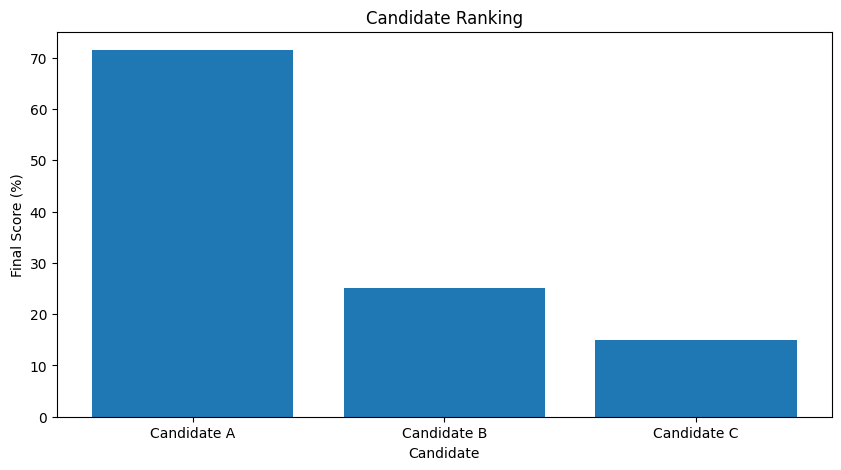

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    ranking["Candidate"],
    ranking["Final Score"]
)

plt.xlabel("Candidate")
plt.ylabel("Final Score (%)")
plt.title("Candidate Ranking")

plt.show()

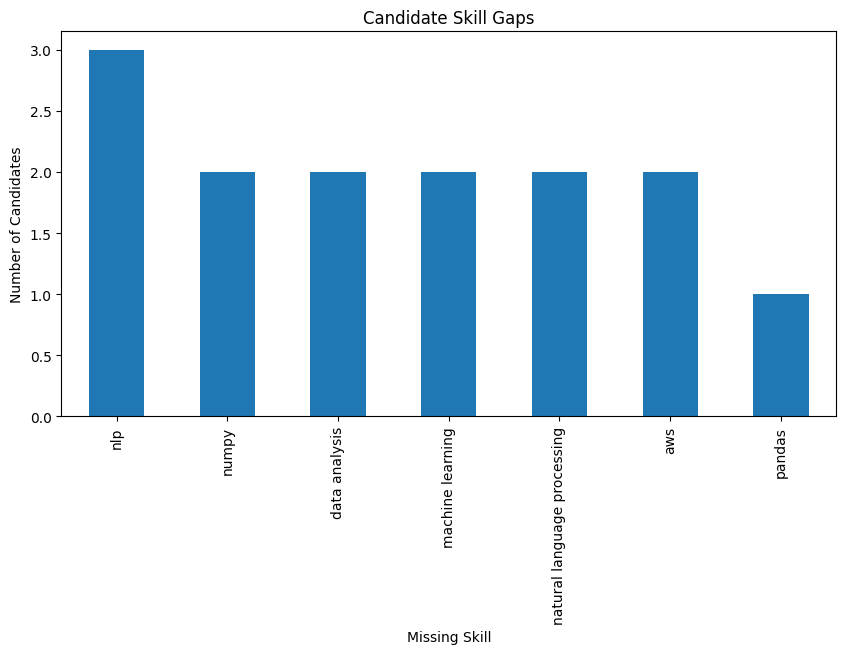

In [ ]:
all_missing = []

for skills_list in ranking["Missing Skills"]:
    all_missing.extend(skills_list)

missing_counts = pd.Series(all_missing).value_counts()

missing_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Missing Skill")
plt.ylabel("Number of Candidates")
plt.title("Candidate Skill Gaps")

plt.show()

In [ ]:
from google.colab import files
import pandas as pd

# Upload CSV file
uploaded = files.upload()

# Get uploaded file name
filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

# Read CSV
job_df = pd.read_csv(filename)

print("First 5 rows:")
display(job_df.head())

print("Shape:", job_df.shape)

print("Columns:")
print(job_df.columns.tolist())

Saving monster_com-job_sample.csv to monster_com-job_sample.csv
Uploaded file: monster_com-job_sample.csv
First 5 rows:


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
0,United States of America,US,NaN,No,jobs.monster.com,TeamSoft is seeing an IT Support Specialist to...,IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702",NaN,http://jobview.monster.com/it-support-technici...,NaN,IT/Software Development,11d599f229a80023d2f40e7c52cd941e
1,United States of America,US,NaN,No,jobs.monster.com,The Wisconsin State Journal is seeking a flexi...,Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-e...,NaN,NaN,e4cbb126dabf22159aff90223243ff2a
2,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job DePuy Synthes Co...,Johnson & Johnson Family of Companies Job Appl...,"Full Time, Employee",DePuy Synthes Companies is a member of Johnson...,Personal and Household Services,http://jobview.monster.com/senior-training-lea...,NaN,NaN,839106b353877fa3d896ffb9c1fe01c0
3,United States of America,US,NaN,No,jobs.monster.com,Why Join Altec? If you’re considering a career...,Engineer - Quality Job in Dixon,Full Time,"Dixon, CA",Altec Industries,http://jobview.monster.com/engineer-quality-jo...,NaN,Experienced (Non-Manager),58435fcab804439efdcaa7ecca0fd783
4,United States of America,US,NaN,No,jobs.monster.com,Position ID# 76162 # Positions 1 State CT C...,Shift Supervisor - Part-Time Job in Camphill,Full Time Employee,"Camphill, PA",Retail,http://jobview.monster.com/shift-supervisor-pa...,NaN,Project/Program Management,64d0272dc8496abfd9523a8df63c184c


Shape: (22000, 14)
Columns:
['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']


In [ ]:
job_roles = {
    "Data Scientist": """
    Python SQL machine learning NLP pandas numpy scikit-learn AWS
    """,

    "Data Analyst": """
    Python SQL Excel Power BI data analysis statistics visualization
    """,

    "Python Developer": """
    Python Django Flask SQL REST API Git
    """,

    "ML Engineer": """
    Python machine learning deep learning TensorFlow PyTorch
    scikit-learn SQL AWS
    """,

    "Software Developer": """
    Python Java SQL Git software development REST API
    """,

    "NLP Engineer": """
    Python NLP natural language processing machine learning
    NLTK spaCy transformers deep learning
    """
}

print("Available Job Roles:")
for role in job_roles:
    print("-", role)

Available Job Roles:
- Data Scientist
- Data Analyst
- Python Developer
- ML Engineer
- Software Developer
- NLP Engineer


In [ ]:
# Select job role
selected_role = "Data Scientist"

# Get job description
job_description = job_roles[selected_role]

print("Selected Role:", selected_role)
print("Job Description:", job_description)

# Required skills
required_skills = [
    "python",
    "sql",
    "machine learning",
    "nlp",
    "pandas",
    "numpy",
    "scikit-learn",
    "aws"
]

# Calculate skill match
def calculate_skill_match(resume_text, required_skills):
    resume_text = resume_text.lower()

    matched_skills = []

    for skill in required_skills:
        if skill.lower() in resume_text:
            matched_skills.append(skill)

    skill_score = (len(matched_skills) / len(required_skills)) * 100

    return skill_score, matched_skills

print("Step 20 ready!")

Selected Role: Data Scientist
Job Description: 
    Python SQL machine learning NLP pandas numpy scikit-learn AWS
    
Step 20 ready!


In [ ]:
print("Available variables:")
print([x for x in globals() if not x.startswith("_")])

Available variables:
['In', 'Out', 'get_ipython', 'exit', 'quit', 'pd', 'files', 'os', 'uploaded', 'filename', 'job_df', 'job_roles', 'role', 'selected_role', 'job_description', 'required_skills', 'calculate_skill_match', 'plt']


In [ ]:
import pandas as pd

dataframes = []

for name in list(globals().keys()):
    value = globals()[name]

    if isinstance(value, pd.DataFrame):
        dataframes.append(name)

print("Available DataFrames:")
for name in dataframes:
    print("-", name)

Available DataFrames:
- job_df


In [ ]:
print("Columns:")
print(job_df.columns.tolist())

print("\nShape:")
print(job_df.shape)

print("\nFirst 5 rows:")
display(job_df.head())

Columns:
['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']

Shape:
(22000, 14)

First 5 rows:


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
0,United States of America,US,NaN,No,jobs.monster.com,TeamSoft is seeing an IT Support Specialist to...,IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702",NaN,http://jobview.monster.com/it-support-technici...,NaN,IT/Software Development,11d599f229a80023d2f40e7c52cd941e
1,United States of America,US,NaN,No,jobs.monster.com,The Wisconsin State Journal is seeking a flexi...,Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-e...,NaN,NaN,e4cbb126dabf22159aff90223243ff2a
2,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job DePuy Synthes Co...,Johnson & Johnson Family of Companies Job Appl...,"Full Time, Employee",DePuy Synthes Companies is a member of Johnson...,Personal and Household Services,http://jobview.monster.com/senior-training-lea...,NaN,NaN,839106b353877fa3d896ffb9c1fe01c0
3,United States of America,US,NaN,No,jobs.monster.com,Why Join Altec? If you’re considering a career...,Engineer - Quality Job in Dixon,Full Time,"Dixon, CA",Altec Industries,http://jobview.monster.com/engineer-quality-jo...,NaN,Experienced (Non-Manager),58435fcab804439efdcaa7ecca0fd783
4,United States of America,US,NaN,No,jobs.monster.com,Position ID# 76162 # Positions 1 State CT C...,Shift Supervisor - Part-Time Job in Camphill,Full Time Employee,"Camphill, PA",Retail,http://jobview.monster.com/shift-supervisor-pa...,NaN,Project/Program Management,64d0272dc8496abfd9523a8df63c184c


In [ ]:
print("Job Dataset Columns:")
for col in job_df.columns:
    print("-", col)

print("\nDataset Shape:")
print(job_df.shape)

print("\nFirst 5 Rows:")
display(job_df.head())

Job Dataset Columns:
- country
- country_code
- date_added
- has_expired
- job_board
- job_description
- job_title
- job_type
- location
- organization
- page_url
- salary
- sector
- uniq_id

Dataset Shape:
(22000, 14)

First 5 Rows:


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
0,United States of America,US,NaN,No,jobs.monster.com,TeamSoft is seeing an IT Support Specialist to...,IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702",NaN,http://jobview.monster.com/it-support-technici...,NaN,IT/Software Development,11d599f229a80023d2f40e7c52cd941e
1,United States of America,US,NaN,No,jobs.monster.com,The Wisconsin State Journal is seeking a flexi...,Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-e...,NaN,NaN,e4cbb126dabf22159aff90223243ff2a
2,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job DePuy Synthes Co...,Johnson & Johnson Family of Companies Job Appl...,"Full Time, Employee",DePuy Synthes Companies is a member of Johnson...,Personal and Household Services,http://jobview.monster.com/senior-training-lea...,NaN,NaN,839106b353877fa3d896ffb9c1fe01c0
3,United States of America,US,NaN,No,jobs.monster.com,Why Join Altec? If you’re considering a career...,Engineer - Quality Job in Dixon,Full Time,"Dixon, CA",Altec Industries,http://jobview.monster.com/engineer-quality-jo...,NaN,Experienced (Non-Manager),58435fcab804439efdcaa7ecca0fd783
4,United States of America,US,NaN,No,jobs.monster.com,Position ID# 76162 # Positions 1 State CT C...,Shift Supervisor - Part-Time Job in Camphill,Full Time Employee,"Camphill, PA",Retail,http://jobview.monster.com/shift-supervisor-pa...,NaN,Project/Program Management,64d0272dc8496abfd9523a8df63c184c


In [ ]:
print(job_df.columns.tolist())

['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']


In [ ]:
# Select job title and job description
job_data = job_df[["job_title", "job_description"]].copy()

# Remove empty job descriptions
job_data = job_data.dropna(subset=["job_description"])

print("Number of job descriptions:", len(job_data))

print("\nSample job descriptions:")
display(job_data.head())

Number of job descriptions: 22000

Sample job descriptions:


,job_title,job_description
0,IT Support Technician Job in Madison,TeamSoft is seeing an IT Support Specialist to...
1,Business Reporter/Editor Job in Madison,The Wisconsin State Journal is seeking a flexi...
2,Johnson & Johnson Family of Companies Job Appl...,Report this job About the Job DePuy Synthes Co...
3,Engineer - Quality Job in Dixon,Why Join Altec? If you’re considering a career...
4,Shift Supervisor - Part-Time Job in Camphill,Position ID# 76162 # Positions 1 State CT C...


In [ ]:
candidate_resumes = {
    "Candidate A": """
    Python SQL machine learning NLP pandas numpy scikit-learn AWS
    """,

    "Candidate B": """
    Python SQL Excel Power BI data analysis statistics visualization
    """,

    "Candidate C": """
    Java HTML CSS JavaScript SQL basic Python
    """
}

print("Candidates:")
for candidate in candidate_resumes:
    print("-", candidate)

Candidates:
- Candidate A
- Candidate B
- Candidate C


In [ ]:
# Get job description from job_df
job_data = job_df[["job_title", "job_description"]].dropna(
    subset=["job_description"]
).copy()

# Select first job
selected_job_title = job_data.iloc[0]["job_title"]
selected_job_description = str(job_data.iloc[0]["job_description"])

print("Selected Job Title:")
print(selected_job_title)

# Candidate resumes
candidate_resumes = {
    "Candidate A": """
    Python SQL machine learning NLP pandas numpy scikit-learn AWS
    """,

    "Candidate B": """
    Python SQL Excel Power BI data analysis statistics visualization
    """,

    "Candidate C": """
    Java HTML CSS JavaScript SQL basic Python
    """
}

# Skills list
skills = [
    "python",
    "sql",
    "machine learning",
    "nlp",
    "pandas",
    "numpy",
    "scikit-learn",
    "aws",
    "excel",
    "power bi",
    "statistics",
    "data analysis",
    "visualization",
    "java",
    "javascript",
    "html",
    "css"
]

# Find required skills in job description
job_text = selected_job_description.lower()

required_skills = []

for skill in skills:
    if skill in job_text:
        required_skills.append(skill)

print("\nRequired Skills:")
print(required_skills)

# Calculate skill match
skill_scores = {}
matched_skills_dict = {}

for candidate, resume in candidate_resumes.items():

    resume_text = resume.lower()
    matched = []

    for skill in required_skills:
        if skill in resume_text:
            matched.append(skill)

    if len(required_skills) > 0:
        score = (len(matched) / len(required_skills)) * 100
    else:
        score = 0

    skill_scores[candidate] = score
    matched_skills_dict[candidate] = matched

print("\nSkill Match Scores:")

for candidate in candidate_resumes:
    print(
        candidate,
        ":",
        round(skill_scores[candidate], 2),
        "%",
        "| Matched:",
        matched_skills_dict[candidate]
    )

Selected Job Title:
IT Support Technician Job in Madison

Required Skills:
[]

Skill Match Scores:
Candidate A : 0 % | Matched: []
Candidate B : 0 % | Matched: []
Candidate C : 0 % | Matched: []


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --------------------------------
# 1. Get job description
# --------------------------------

job_data = job_df[["job_title", "job_description"]].dropna(
    subset=["job_description"]
).copy()

selected_job_title = job_data.iloc[0]["job_title"]
selected_job_description = str(job_data.iloc[0]["job_description"])

print("Selected Job:")
print(selected_job_title)


# --------------------------------
# 2. Candidate resumes
# --------------------------------

candidate_resumes = {
    "Candidate A": """
    Python SQL machine learning NLP pandas numpy scikit-learn AWS
    """,

    "Candidate B": """
    Python SQL Excel Power BI data analysis statistics visualization
    """,

    "Candidate C": """
    Java HTML CSS JavaScript SQL basic Python
    """
}


# --------------------------------
# 3. Text Similarity
# --------------------------------

texts = list(candidate_resumes.values()) + [
    selected_job_description
]

vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(texts)

similarity_scores = cosine_similarity(
    tfidf_matrix[:-1],
    tfidf_matrix[-1]
).flatten() * 100


# --------------------------------
# 4. Required Skills
# --------------------------------

skills = [
    "python",
    "sql",
    "machine learning",
    "nlp",
    "pandas",
    "numpy",
    "scikit-learn",
    "aws",
    "excel",
    "power bi",
    "statistics",
    "data analysis",
    "visualization",
    "java",
    "javascript",
    "html",
    "css"
]

job_text = selected_job_description.lower()

required_skills = [
    skill for skill in skills
    if skill in job_text
]

print("\nRequired Skills:")
print(required_skills)


# --------------------------------
# 5. Skill Match
# --------------------------------

skill_scores = {}
matched_skills_dict = {}

for candidate, resume in candidate_resumes.items():

    resume_text = resume.lower()

    matched = [
        skill for skill in required_skills
        if skill in resume_text
    ]

    if len(required_skills) > 0:
        score = (len(matched) / len(required_skills)) * 100
    else:
        score = 0

    skill_scores[candidate] = score
    matched_skills_dict[candidate] = matched


# --------------------------------
# 6. Final Score
# --------------------------------

ranking = pd.DataFrame({
    "Candidate": list(candidate_resumes.keys()),
    "Text Similarity": similarity_scores,
    "Skill Match": [
        skill_scores[candidate]
        for candidate in candidate_resumes
    ]
})

ranking["Final Score"] = (
    0.60 * ranking["Text Similarity"] +
    0.40 * ranking["Skill Match"]
)


# --------------------------------
# 7. Candidate Ranking
# --------------------------------

ranking = ranking.sort_values(
    by="Final Score",
    ascending=False
).reset_index(drop=True)

ranking["Rank"] = range(1, len(ranking) + 1)

ranking = ranking[
    [
        "Rank",
        "Candidate",
        "Text Similarity",
        "Skill Match",
        "Final Score"
    ]
]

ranking[
    ["Text Similarity", "Skill Match", "Final Score"]
] = ranking[
    ["Text Similarity", "Skill Match", "Final Score"]
].round(2)


# --------------------------------
# 8. Display Final Result
# --------------------------------

print("\nFINAL CANDIDATE RANKING")

display(ranking)

Selected Job:
IT Support Technician Job in Madison

Required Skills:
[]

FINAL CANDIDATE RANKING


,Rank,Candidate,Text Similarity,Skill Match,Final Score
0,1,Candidate B,0.88,0,0.53
1,2,Candidate A,0.00,0,0.00
2,3,Candidate C,0.00,0,0.00


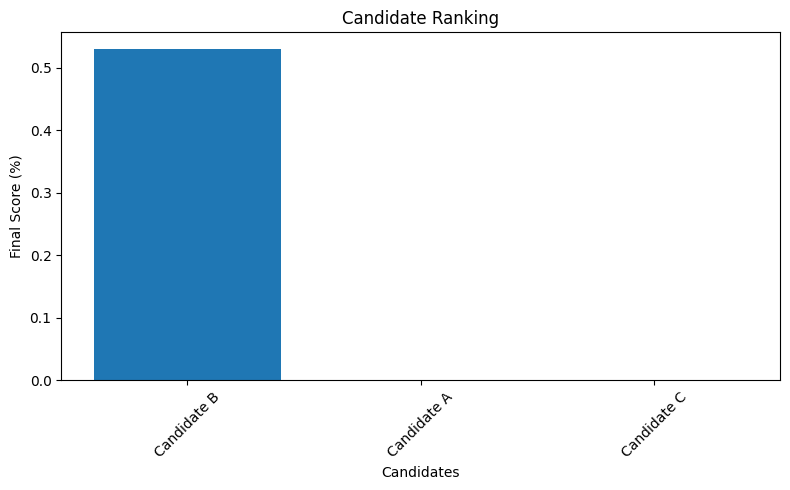

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    ranking["Candidate"],
    ranking["Final Score"]
)

plt.xlabel("Candidates")
plt.ylabel("Final Score (%)")
plt.title("Candidate Ranking")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("candidate_ranking.png")
plt.show()

In [ ]:
# Create skill gap information

skill_gap_data = []

for candidate in candidate_resumes:

    matched = matched_skills_dict[candidate]

    missing = [
        skill
        for skill in required_skills
        if skill not in matched
    ]

    skill_gap_data.append({
        "Candidate": candidate,
        "Matched Skills": ", ".join(matched) if matched else "None",
        "Missing Skills": ", ".join(missing) if missing else "None"
    })

skill_gap_df = pd.DataFrame(skill_gap_data)

print("SKILL GAP ANALYSIS")

display(skill_gap_df)

SKILL GAP ANALYSIS


,Candidate,Matched Skills,Missing Skills
0,Candidate A,None,None
1,Candidate B,None,None
2,Candidate C,None,None


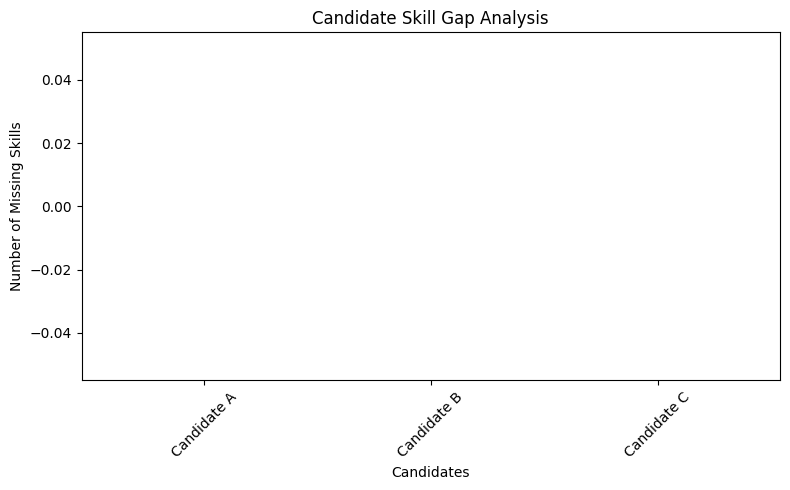

In [ ]:
import matplotlib.pyplot as plt

# Count missing skills for each candidate
missing_counts = []

for candidate in candidate_resumes:
    missing = [
        skill
        for skill in required_skills
        if skill not in matched_skills_dict[candidate]
    ]
    missing_counts.append(len(missing))

# Create graph
plt.figure(figsize=(8, 5))

plt.bar(
    candidate_resumes.keys(),
    missing_counts
)

plt.xlabel("Candidates")
plt.ylabel("Number of Missing Skills")
plt.title("Candidate Skill Gap Analysis")

plt.xticks(rotation=45)
plt.tight_layout()

# Save graph
plt.savefig("skill_gap.png")

plt.show()

In [ ]:
# Save final results as CSV files

ranking.to_csv("candidate_ranking.csv", index=False)

skill_gap_df.to_csv("skill_gap_analysis.csv", index=False)

print("Files saved successfully!")
print("1. candidate_ranking.csv")
print("2. skill_gap_analysis.csv")

Files saved successfully!
1. candidate_ranking.csv
2. skill_gap_analysis.csv


In [ ]:
from google.colab import files

# Download final ranking
files.download("candidate_ranking.csv")

# Download skill gap analysis
files.download("skill_gap_analysis.csv")

# Download ranking graph
files.download("candidate_ranking.png")

# Download skill gap graph
files.download("skill_gap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("===== FINAL PROJECT CHECK =====\n")

print("1. Candidate Ranking:")
display(ranking)

print("\n2. Skill Gap Analysis:")
display(skill_gap_df)

print("\n3. Required Skills:")
print(required_skills)

print("\n4. Saved Files:")

import os

files_to_check = [
    "candidate_ranking.csv",
    "skill_gap_analysis.csv",
    "candidate_ranking.png",
    "skill_gap.png"
]

for file in files_to_check:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

===== FINAL PROJECT CHECK =====

1. Candidate Ranking:


,Rank,Candidate,Text Similarity,Skill Match,Final Score
0,1,Candidate B,0.88,0,0.53
1,2,Candidate A,0.00,0,0.00
2,3,Candidate C,0.00,0,0.00



2. Skill Gap Analysis:


,Candidate,Matched Skills,Missing Skills
0,Candidate A,None,None
1,Candidate B,None,None
2,Candidate C,None,None



3. Required Skills:
[]

4. Saved Files:
✅ candidate_ranking.csv
✅ skill_gap_analysis.csv
✅ candidate_ranking.png
✅ skill_gap.png
